In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
features = pd.read_csv("features.csv")
labels = pd.read_csv("labels.csv")
population = pd.read_csv("population.csv")

In [ ]:
print(features.columns)
print(labels.columns)
print(population.columns)

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm'],
      dtype='object')
Index(['city', 'year', 'weekofyear', 'total_cases'], dtype='object')
Index(['city', 'year', 'population', 'population_density'], dtype='object')


In [ ]:
population.columns

Index(['city', 'year', 'population', 'population_density'], dtype='object')

In [ ]:
df = pd.merge(
    features,
    labels,
    on=['city', 'year', 'weekofyear']
)

In [ ]:
df = pd.merge(
    df,
    population,
    on=['city', 'year'],
    how='left'
)

In [ ]:
print(df.shape)
df.head()

(1456, 27)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,population,population_density
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4,395000.0,7200.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5,395000.0,7200.0
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4,395000.0,7200.0
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3,395000.0,7200.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6,395000.0,7200.0


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

In [ ]:
df = df.drop(
    columns=[
        'city',
        'week_start_date'
    ]
)

In [ ]:
X = df.drop(columns=['total_cases'])

y = df['total_cases']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,2))

MAE : 14.56
RMSE: 34.77
R² : 0.62


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
1,weekofyear,0.222415
22,population,0.116232
23,population_density,0.115664
0,year,0.114549
15,reanalysis_specific_humidity_g_per_kg,0.060346
21,station_precip_mm,0.057071
12,reanalysis_precip_amt_kg_per_m2,0.052957
9,reanalysis_dew_point_temp_k,0.051883
7,reanalysis_air_temp_k,0.035027
11,reanalysis_min_air_temp_k,0.024152


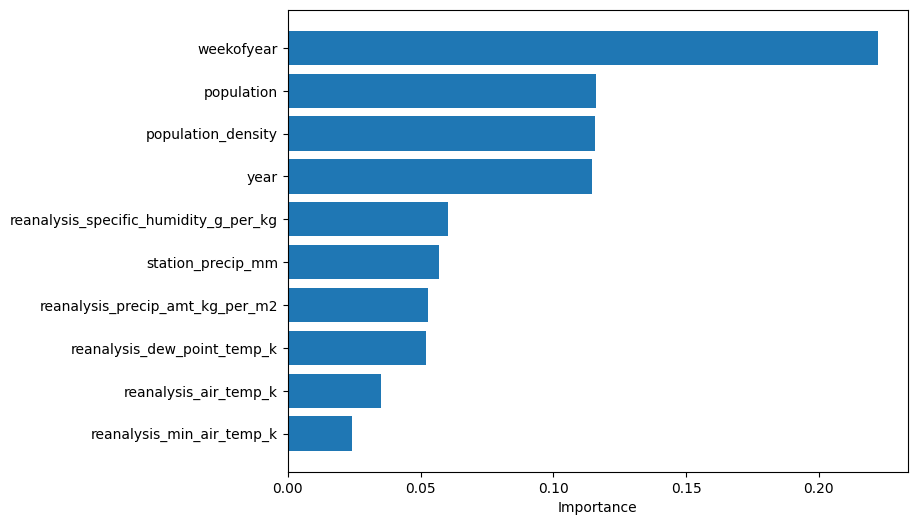

In [ ]:
top = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top['Feature'],
    top['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.show()